# Assignment 2

Viktor Österberg

The use of AI in assignment 2:

In this assignment, AI (Claude) has been used as a supporting tool for coding. The following supporting functions were used: explaining to the author what is wrong in the code and why it is not running, correcting error code, simplifying code so that the structure is easier to understand and the lines of code are not excessively long, which would otherwise add unnecessary bulk to the final file layout. All outputs from the AI tool have been critically evaluated and crosschecked to ensure that the tool does not hallucinate data and final output. 

# Task 0: Course project dataset exploration

# Part A:

Name of dataset: Carbon (CO2) Emissions

Global Carbon Emissions by Country (Historical & Recent Data)

Link to the dataset: https://www.kaggle.com/datasets/ravindrasinghrana/carbon-co2-emissions

# Part B:

The dataset contains CO2 emissions records for 190 countries around the world across multiple years (1990-2019). The whole dataset contains 5677 rows and it has 5 coloumns. The columns are country, region, date, kilotons of CO2, and metric tons per capita.

The preliminary plan for the project with this dataset is to analyse how CO2 emissions have changed over time accross different regions, identify the highest and lowest emitting countries, and explore the relationship between total emissions and per capita emissions 

In [1]:
# Part C: CO2 Emissions dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
co2_df = pd.read_csv("Carbon_(CO2)_Emissions_by_Country (1).csv")

# Parse date
co2_df["Date"] = pd.to_datetime(co2_df["Date"], dayfirst=True)

print(f"Shape: {co2_df.shape}")
display(co2_df.head())

# The first five rows of the dataset are shown in the output

Shape: (5677, 5)


,Country,Region,Date,Kilotons of Co2,Metric Tons Per Capita
0,Afghanistan,Asia,2011-01-01,8930.0,0.31
1,Afghanistan,Asia,2012-01-01,8080.0,0.27
2,Afghanistan,Asia,2010-01-01,7110.0,0.25
3,Afghanistan,Asia,2019-01-01,6080.0,0.16
4,Afghanistan,Asia,2018-01-01,6070.0,0.17


In [2]:
# Summary statistics (rounded to two decimals)
display(co2_df.describe().round(2))

,Date,Kilotons of Co2,Metric Tons Per Capita
count,5677,5677.00,5677.00
mean,2004-07-17 20:37:34.993834880,141229.16,4.33
min,1990-01-01 00:00:00,0.00,0.00
25%,1997-01-01 00:00:00,1380.00,0.57
50%,2005-01-01 00:00:00,9170.00,2.36
75%,2012-01-01 00:00:00,58480.00,6.34
max,2019-01-01 00:00:00,10707219.73,47.65
std,NaN,649125.82,5.50


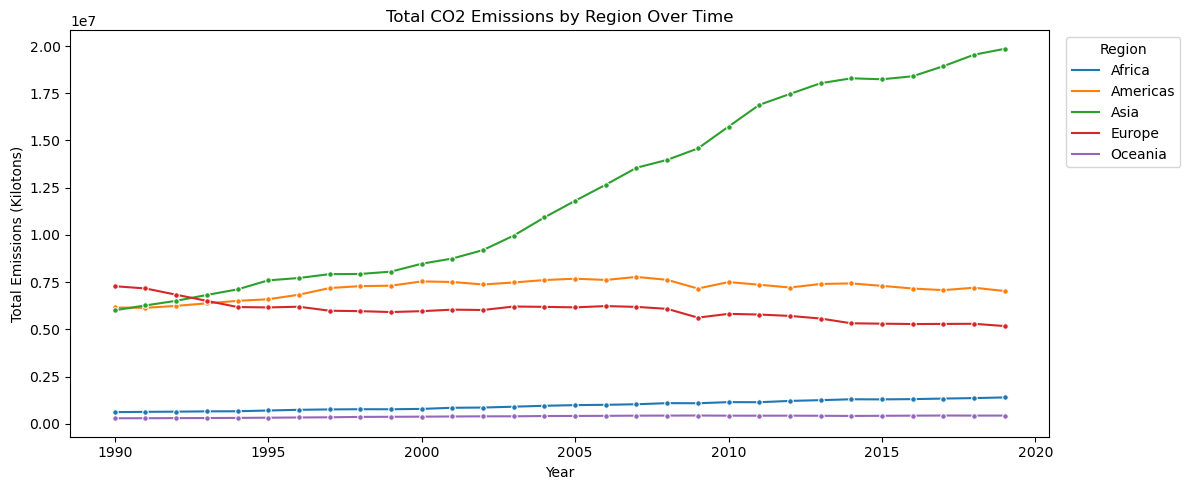

In [3]:
# Visualization 1: Total CO2 emissions per region over time
region_year = (
    co2_df.groupby([co2_df["Date"].dt.year, "Region"])["Kilotons of Co2"]
    .sum()
    .reset_index()
    .rename(columns={"Date": "Year"})
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=region_year, x="Year", y="Kilotons of Co2",
             hue="Region", marker="o", markersize=4, ax=ax)
ax.set_title("Total CO2 Emissions by Region Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Total Emissions (Kilotons)")
ax.legend(title="Region", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

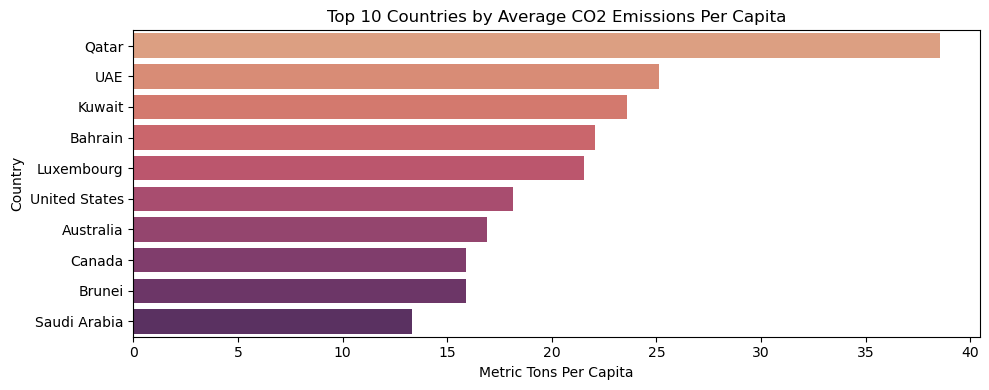

In [4]:
# Visualization 2: Top 10 countries by average per capita emissions
top10_capita = (
    co2_df.groupby("Country")["Metric Tons Per Capita"]
    .mean()
    .reset_index()
    .sort_values("Metric Tons Per Capita", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=top10_capita, x="Metric Tons Per Capita", y="Country",
            palette="flare", ax=ax)
ax.set_title("Top 10 Countries by Average CO2 Emissions Per Capita")
ax.set_xlabel("Metric Tons Per Capita")
ax.set_ylabel("Country")
plt.tight_layout()
plt.show()

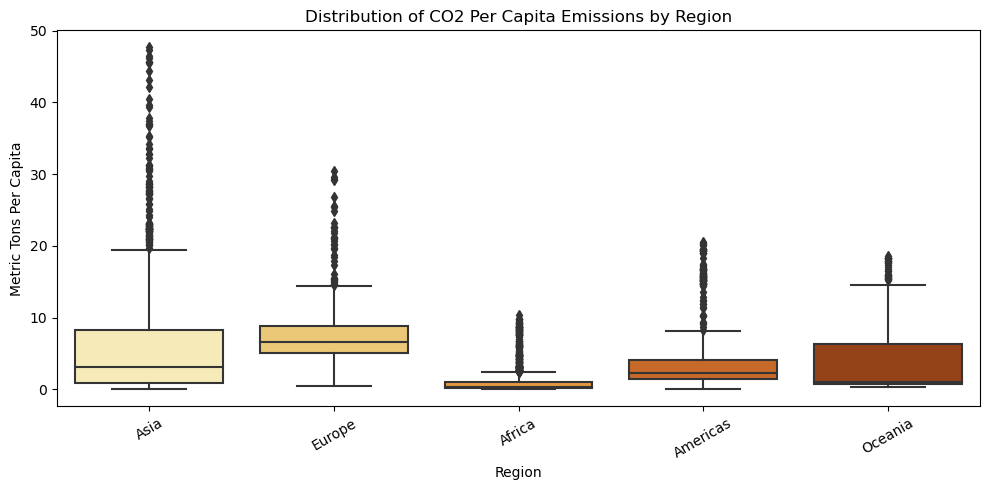

In [5]:
# Visualization 3: Distribution of per capita emissions by region
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=co2_df, x="Region", y="Metric Tons Per Capita",
            palette="YlOrBr", ax=ax)
ax.set_title("Distribution of CO2 Per Capita Emissions by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Metric Tons Per Capita")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Task 1: Setting up an API key and .env file

In [6]:
# Load API key from .env file
from dotenv import load_dotenv
import os

load_dotenv("env")  # My filename

api_key = os.getenv("MARKETSTACK_API_KEY")

if api_key is None:
    raise ValueError("API key not found. Make sure MARKETSTACK_API_KEY is set in your .env file.")

print(api_key[:5] + "...")

b9947...


# Task 2: Retrieving data from MarketStack

In [7]:
# Part A: Retrieving EOD data for FAANG stocks for March 2026
import requests
import pandas as pd

FAANG_TICKERS = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]
BASE_URL = "http://api.marketstack.com/v1/eod"

all_data = []

for ticker in FAANG_TICKERS:
    params = {
        "access_key": api_key,
        "symbols": ticker,
        "date_from": "2026-03-01",
        "date_to": "2026-03-31",
        "limit": 50,
    }
    response = requests.get(BASE_URL, params=params)
    response.raise_for_status()
    data = response.json()
    all_data.extend(data["data"])
    print(f"{ticker}: {len(data['data'])} trading days retrieved")

print(f"\nTotal records fetched: {len(all_data)}")

META: 22 trading days retrieved
AAPL: 22 trading days retrieved
AMZN: 22 trading days retrieved
NFLX: 22 trading days retrieved
GOOG: 22 trading days retrieved

Total records fetched: 110


In [8]:
# Part B: Converting to DataFrame and printing first 5 rows
stocks_df = pd.DataFrame(all_data)
stocks_df["date"] = pd.to_datetime(stocks_df["date"]).dt.date
stocks_df = stocks_df.sort_values(["symbol", "date"]).reset_index(drop=True)

display(stocks_df.head())

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,262.440,266.530,260.20,264.72,41576035.0,266.530,260.20,264.72,262.41,41827946.0,1.0,0.0,AAPL,XNAS,2026-03-02
1,263.480,265.560,260.13,263.75,37994695.0,265.560,260.13,263.75,263.48,38568921.0,1.0,0.0,AAPL,XNAS,2026-03-03
2,264.650,266.150,261.42,262.52,39258957.0,266.150,261.42,262.52,264.65,39803119.0,1.0,0.0,AAPL,XNAS,2026-03-04
3,260.745,261.555,257.25,260.29,49424671.0,261.555,257.25,260.29,260.79,49658626.0,1.0,0.0,AAPL,XNAS,2026-03-05
4,258.740,258.760,254.37,257.46,40628988.0,258.770,254.37,257.46,258.63,41120042.0,1.0,0.0,AAPL,XNAS,2026-03-06


In [9]:
# Part C: Summary statistics and monthly return per stock

# Summary statistics for closing prices grouped by ticker
close_stats = stocks_df.groupby("symbol")["close"].describe()
print("Closing price summary statistics:")
display(close_stats)

# Monthly return = (last close - first close) / first close * 100
def monthly_return(group):
    first = group.sort_values("date").iloc[0]["close"]
    last  = group.sort_values("date").iloc[-1]["close"]
    return round((last - first) / first * 100, 2)

returns = stocks_df.groupby("symbol").apply(monthly_return).reset_index()
returns.columns = ["symbol", "return_pct"]
returns = returns.sort_values("return_pct", ascending=False).reset_index(drop=True)

print("\nMonthly return (%) per stock in March 2026:")
display(returns)

print(f"\nBest performer: {returns.iloc[0]['symbol']} ({returns.iloc[0]['return_pct']:+.2f}%)")
print(f"Worst performer: {returns.iloc[-1]['symbol']} ({returns.iloc[-1]['return_pct']:+.2f}%)")

Closing price summary statistics:


,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
AAPL,22.0,254.906364,5.510351,246.63,250.4625,253.340,260.1875,264.72
AMZN,22.0,209.995000,4.643217,199.34,207.8200,209.700,213.0700,218.94
GOOG,22.0,297.980455,10.928636,273.14,291.7675,302.335,305.9400,309.41
META,22.0,614.990909,41.309579,525.72,593.9675,619.170,652.0175,667.73
NFLX,22.0,95.076364,2.512109,90.92,93.3350,94.795,97.0525,99.17



Monthly return (%) per stock in March 2026:


,symbol,return_pct
0,AMZN,-0.06
1,NFLX,-0.97
2,AAPL,-4.13
3,GOOG,-6.37
4,META,-12.46



Best performer: AMZN (-0.06%)
Worst performer: META (-12.46%)


# Task 3: Visualizing stock data 

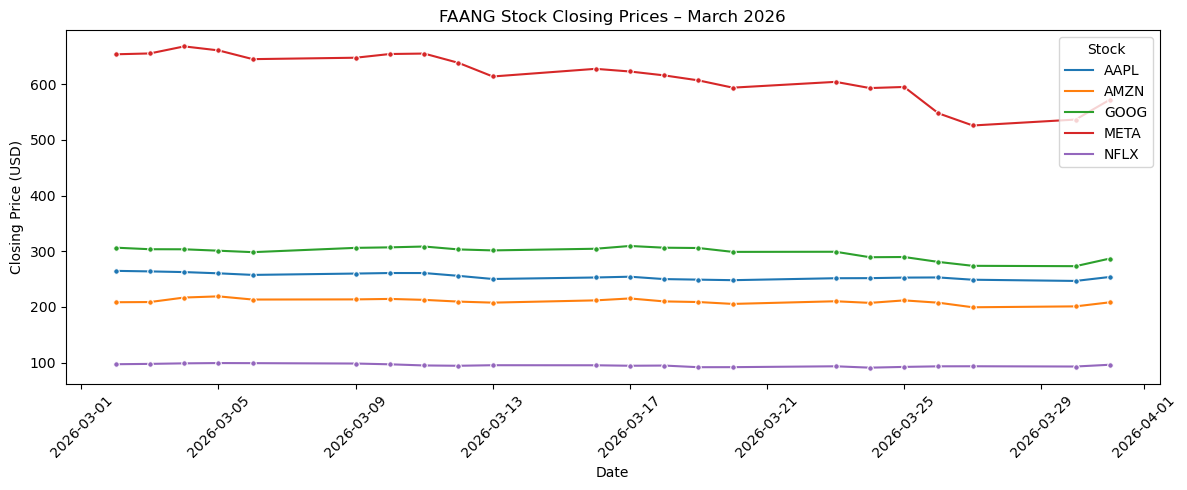

In [10]:
# Part A: Closing price over time (Line chart)
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(
    data=stocks_df,
    x="date",
    y="close",
    hue="symbol",
    marker="o",
    markersize=4,
    ax=ax
)
ax.set_title("FAANG Stock Closing Prices – March 2026")
ax.set_xlabel("Date")
ax.set_ylabel("Closing Price (USD)")
ax.legend(title="Stock")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

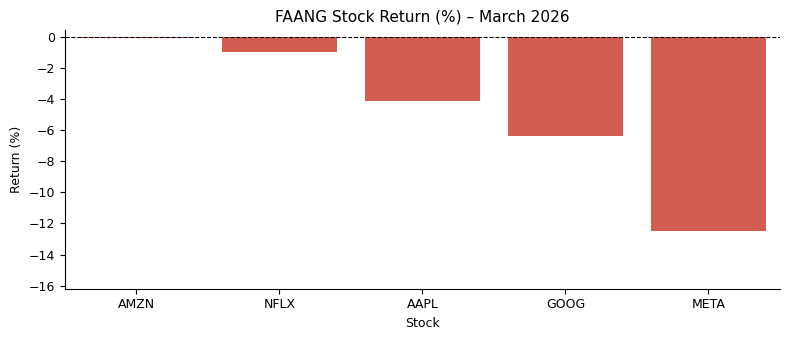

In [11]:
# Part B: monthly return percentage per stock (bar plot)
fig, ax = plt.subplots(figsize=(8, 3.5))

palette = ["#2ecc71" if r >= 0 else "#e74c3c" for r in returns["return_pct"]]
sns.barplot(data=returns, x="symbol", y="return_pct", palette=palette, ax=ax)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

current_min = returns["return_pct"].min()
ax.set_ylim(current_min * 1.3, returns["return_pct"].max() * 1.3 + 0.5)

# Value labels inside bars
for bar, val in zip(ax.patches, returns["return_pct"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() - 0.2,
        f"{val:+.2f}%",
        ha="center",
        va="top",
        fontsize=9,
        fontweight="bold",
        color="white"
    )

ax.set_title("FAANG Stock Return (%) – March 2026", fontsize=11)
ax.set_xlabel("Stock", fontsize=9)
ax.set_ylabel("Return (%)", fontsize=9)
ax.tick_params(labelsize=9)
sns.despine()
plt.tight_layout()
plt.show()

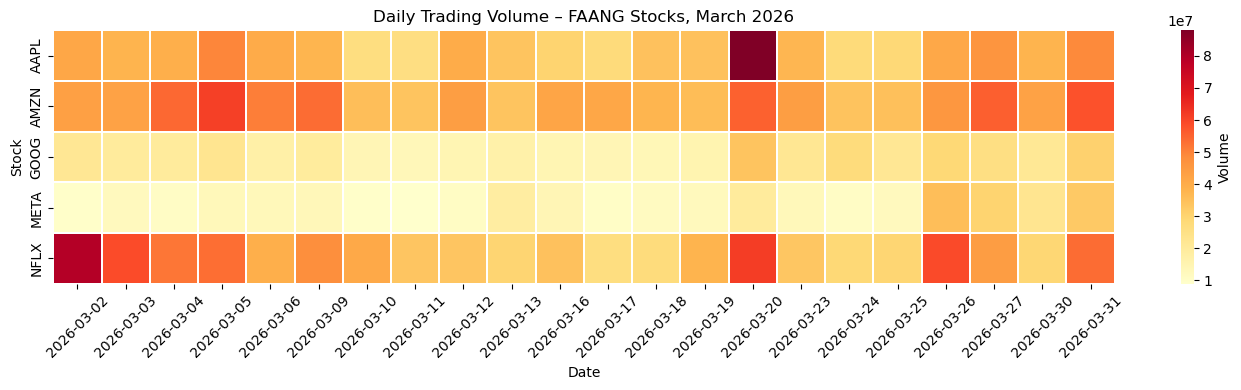

In [12]:
# Part C: daily trading volume on a heatmap (stocks on y-axis, dates on x-axis)
volume_pivot = stocks_df.pivot(index="symbol", columns="date", values="volume")

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    volume_pivot,
    cmap="YlOrRd",
    ax=ax,
    linewidths=0.3,
    cbar_kws={"label": "Volume"}
)
ax.set_title("Daily Trading Volume – FAANG Stocks, March 2026")
ax.set_xlabel("Date")
ax.set_ylabel("Stock")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Task 4: Exporting and importing data

In [13]:
# Part A: Exporting raw JSON data to exports/stockdata.json
import json
from pathlib import Path

exports_dir = Path("exports")
exports_dir.mkdir(exist_ok=True)  # create the folder if it doesn't exist

json_path = exports_dir / "stockdata.json"

with open(json_path, "w") as f:
    json.dump(all_data, f, indent=2, default=str)

print(f"JSON saved to: {json_path}")

JSON saved to: exports\stockdata.json


In [14]:
# Part B: Exporting DataFrame to exports/stockdata.csv
csv_path = exports_dir / "stockdata.csv"

stocks_df.to_csv(csv_path, index=False)

print(f"CSV saved to: {csv_path}")

CSV saved to: exports\stockdata.csv


In [15]:
# Part C: Reloading both files and verifying that they match the original

# Reloading JSON
with open(json_path, "r") as f:
    reloaded_json = json.load(f)

json_df = pd.DataFrame(reloaded_json)
json_df["date"] = pd.to_datetime(json_df["date"]).dt.date

print("Reloaded JSON (first 5 rows):")
display(json_df.head())

# Reloading CSV
csv_df = pd.read_csv(csv_path)
csv_df["date"] = pd.to_datetime(csv_df["date"]).dt.date

print("Reloaded CSV (first 5 rows):")
display(csv_df.head())

# Verifying that closing prices and shape match the original
original = set(stocks_df["close"].round(4))
from_csv = set(csv_df["close"].round(4))
print(f"\nClosing prices match original: {original == from_csv}")
print(f"Shapes match: {stocks_df.shape == csv_df.shape}")

Reloaded JSON (first 5 rows):


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,549.98,573.69,546.77,572.13,32809500.0,573.6900,546.77,572.13,549.98,32898272.0,1.0,0.0,META,ARCX,2026-03-31
1,536.38,539.55,528.54,536.38,22758800.0,539.5500,528.54,536.38,536.38,22795203.0,1.0,0.0,META,ARCX,2026-03-30
2,540.10,543.60,520.26,525.72,29980300.0,543.5999,520.26,525.72,540.10,30133010.0,1.0,0.0,META,ARCX,2026-03-27
3,582.49,583.00,543.35,547.54,35664700.0,583.0000,543.35,547.54,582.49,35780131.0,1.0,0.0,META,ARCX,2026-03-26
4,598.74,603.62,593.40,594.89,12161179.0,603.6700,593.40,594.89,598.74,12585031.0,1.0,0.0,META,ARCX,2026-03-25


Reloaded CSV (first 5 rows):


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,262.440,266.530,260.20,264.72,41576035.0,266.530,260.20,264.72,262.41,41827946.0,1.0,0.0,AAPL,XNAS,2026-03-02
1,263.480,265.560,260.13,263.75,37994695.0,265.560,260.13,263.75,263.48,38568921.0,1.0,0.0,AAPL,XNAS,2026-03-03
2,264.650,266.150,261.42,262.52,39258957.0,266.150,261.42,262.52,264.65,39803119.0,1.0,0.0,AAPL,XNAS,2026-03-04
3,260.745,261.555,257.25,260.29,49424671.0,261.555,257.25,260.29,260.79,49658626.0,1.0,0.0,AAPL,XNAS,2026-03-05
4,258.740,258.760,254.37,257.46,40628988.0,258.770,254.37,257.46,258.63,41120042.0,1.0,0.0,AAPL,XNAS,2026-03-06



Closing prices match original: True
Shapes match: True


# Task 5: Querying the Northwind database

In [16]:
# Part A: Connecting to the database and listing all tables
import sqlite3
import pandas as pd

conn = sqlite3.connect("northwind.db")

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
    conn
)
print("Tables in the Northwind database:")
display(tables)

Tables in the Northwind database:


,name
0,Categories
1,CustomerCustomerDemo
2,CustomerDemographics
3,Customers
4,EmployeeTerritories
5,Employees
6,Order Details
7,Orders
8,Products
9,Regions


In [17]:
# Part B: Products with UnitPrice above 30
query_5b = """
SELECT ProductName, UnitPrice, UnitsInStock
FROM Products
WHERE UnitPrice > 30
ORDER BY UnitPrice DESC;
"""

products_df = pd.read_sql_query(query_5b, conn)
print(f"Products with UnitPrice > 30 ({len(products_df)} rows):")
display(products_df)

Products with UnitPrice > 30 (24 rows):


,ProductName,UnitPrice,UnitsInStock
0,Côte de Blaye,263.50,17
1,Thüringer Rostbratwurst,123.79,0
2,Mishi Kobe Niku,97.00,29
3,Sir Rodney's Marmalade,81.00,40
4,Carnarvon Tigers,62.50,42
5,Raclette Courdavault,55.00,79
6,Manjimup Dried Apples,53.00,20
7,Tarte au sucre,49.30,17
8,Ipoh Coffee,46.00,17
9,Rössle Sauerkraut,45.60,26


In [18]:
# Part C: Orders shipped to Germany with line totals
query_5c = """
SELECT c.CompanyName,
       o.OrderID,
       o.OrderDate,
       o.ShipCountry,
       od.UnitPrice * od.Quantity AS LineTotal
FROM Orders o
JOIN Customers c        ON o.CustomerID = c.CustomerID
JOIN 'Order Details' od ON o.OrderID    = od.OrderID
WHERE o.ShipCountry = 'Germany';
"""

germany_df = pd.read_sql_query(query_5c, conn)
germany_df["OrderDate"] = pd.to_datetime(germany_df["OrderDate"], format="mixed")

print(f"Orders shipped to Germany ({len(germany_df)} line items):")
display(germany_df)

Orders shipped to Germany (80673 line items):


,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05 00:00:00,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05 00:00:00,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19 00:00:00,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19 00:00:00,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19 00:00:00,Germany,591.0
...,...,...,...,...,...
80668,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,864.0
80669,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,735.0
80670,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,75.0
80671,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,500.0


# Task 6: Visualizing Northwind data

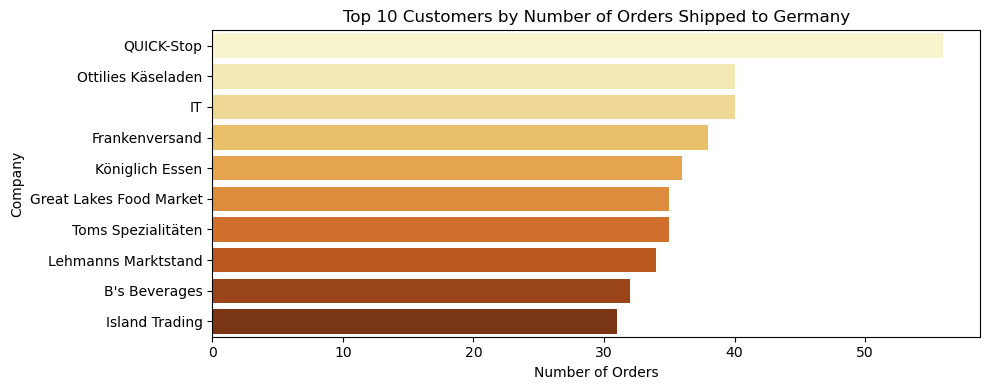

In [19]:
# Part A: Number of orders per customer shown in a bar plot (top 10, Germany)
orders_per_customer = (
    germany_df.groupby("CompanyName")["OrderID"]
    .nunique()
    .reset_index()
    .rename(columns={"OrderID": "num_orders"})
    .sort_values("num_orders", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=orders_per_customer, x="num_orders", y="CompanyName",
            palette="YlOrBr", ax=ax)
ax.set_title("Top 10 Customers by Number of Orders Shipped to Germany")
ax.set_xlabel("Number of Orders")
ax.set_ylabel("Company")
plt.tight_layout()
plt.show()

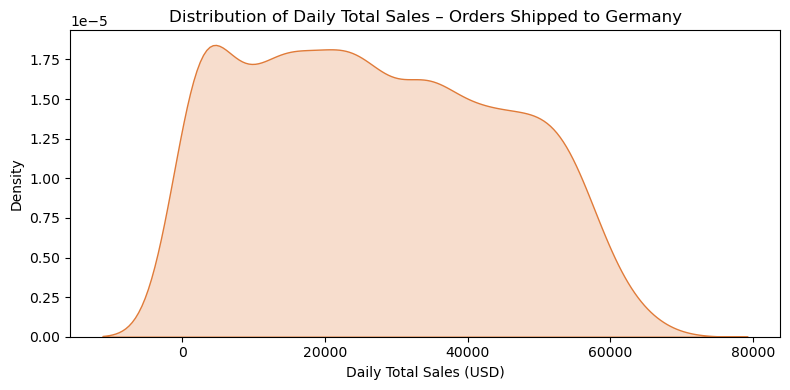

In [20]:
# Part B: Distribution of daily total sales shown in a KDE plot (Germany orders)
daily_sales = (
    germany_df.groupby("OrderDate")["LineTotal"]
    .sum()
    .reset_index()
    .rename(columns={"LineTotal": "DailySales"})
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(daily_sales["DailySales"], fill=True, color="#e07b39", ax=ax)
ax.set_title("Distribution of Daily Total Sales – Orders Shipped to Germany")
ax.set_xlabel("Daily Total Sales (USD)")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

Total revenue by product category:


,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Confections,66347544.94
2,Meat/Poultry,64896314.41
3,Dairy Products,58034940.00
4,Condiments,55802774.45
5,Seafood,49931965.52
6,Produce,32706403.90
7,Grains/Cereals,28573512.55


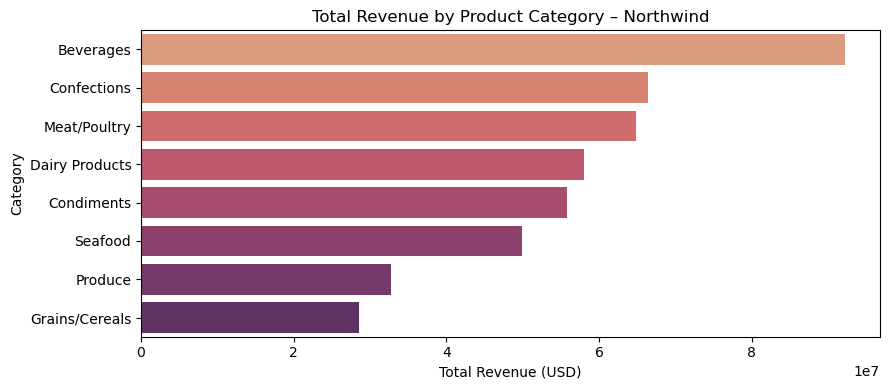

In [21]:
# Part C: Total revenue per product category (SQL query + bar plot)
query_6c = """
SELECT cat.CategoryName,
       SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM 'Order Details' od
JOIN Products p     ON od.ProductID  = p.ProductID
JOIN Categories cat ON p.CategoryID  = cat.CategoryID
GROUP BY cat.CategoryName
ORDER BY TotalRevenue DESC;
"""

revenue_df = pd.read_sql_query(query_6c, conn)
print("Total revenue by product category:")
display(revenue_df)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=revenue_df, x="TotalRevenue", y="CategoryName",
            palette="flare", ax=ax)
ax.set_title("Total Revenue by Product Category – Northwind")
ax.set_xlabel("Total Revenue (USD)")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()

# Task 7: Comparing Python to SQL

In [22]:
# Part A: Retrieve full Products and Categories tables
products_full   = pd.read_sql_query("SELECT * FROM Products;",   conn)
categories_full = pd.read_sql_query("SELECT CategoryID, CategoryName, Description FROM Categories;", conn)

print("Products table (first 5 rows):")
display(products_full.head())

print("Categories table (first 5 rows):")
display(categories_full.head())

Products table (first 5 rows):


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


Categories table (first 5 rows):


,CategoryID,CategoryName,Description
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales"
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an..."
2,3,Confections,"Desserts, candies, and sweet breads"
3,4,Dairy Products,Cheeses
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal"


In [23]:
# Part B: Inner join on CategoryID using pandas
products_with_category = products_full.merge(
    categories_full[["CategoryID", "CategoryName"]],
    on="CategoryID",
    how="inner"
)

print("Products joined with Categories (first 5 rows):")
display(products_with_category.head())

Products joined with Categories (first 5 rows):


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName
0,1,Chai,1,1,10 boxes x 20 bags,18.0,39,0,10,0,Beverages
1,2,Chang,1,1,24 - 12 oz bottles,19.0,17,40,25,0,Beverages
2,24,Guaraná Fantástica,10,1,12 - 355 ml cans,4.5,20,0,0,1,Beverages
3,34,Sasquatch Ale,16,1,24 - 12 oz bottles,14.0,111,0,15,0,Beverages
4,35,Steeleye Stout,16,1,24 - 12 oz bottles,18.0,20,0,15,0,Beverages


In [24]:
# Part C: Speed comparison SQL join vs pandas join
import time

# Method 1: Fully in SQL (as in 6c)
start_sql = time.time()
_ = pd.read_sql_query(query_6c, conn)
time_sql = time.time() - start_sql

# Method 2: Fetch raw tables then join and aggregate in pandas
start_pandas = time.time()
od_full  = pd.read_sql_query("SELECT * FROM 'Order Details';", conn)
p_full   = pd.read_sql_query("SELECT * FROM Products;",        conn)
cat_full = pd.read_sql_query("SELECT * FROM Categories;",      conn)

merged = (
    od_full
    .merge(p_full[["ProductID", "CategoryID"]],      on="ProductID")
    .merge(cat_full[["CategoryID", "CategoryName"]], on="CategoryID")
)
merged["Revenue"] = merged["UnitPrice"] * merged["Quantity"]
_ = merged.groupby("CategoryName")["Revenue"].sum().reset_index()
time_pandas = time.time() - start_pandas

print(f"SQL execution time   : {time_sql:.4f} s")
print(f"Pandas execution time: {time_pandas:.4f} s")
print(f"\n{'SQL' if time_sql < time_pandas else 'Pandas'} was faster.")
print(
    "\nComment: SQL was faster because it processes the data inside the database "
    "and only returns the final result. Pandas had to load all the raw data into "
    "memory first which takes more time."
)

SQL execution time   : 0.9313 s
Pandas execution time: 1.7674 s

SQL was faster.

Comment: SQL was faster because it processes the data inside the database and only returns the final result. Pandas had to load all the raw data into memory first which takes more time.


# Task 8: Wide and long format 

In [25]:
# Defining the two starting DataFrames
wide_data = pd.DataFrame({
    "store":    ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500,  9200],
    "Q2_sales": [13500, 9100,  9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500],
})

long_data = pd.DataFrame({
    "month":      ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product":    ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130],
})

In [26]:
# Part A: Wide to long using pd.melt()
print("wide_data BEFORE melt:")
display(wide_data)

wide_to_long = pd.melt(
    wide_data,
    id_vars="store",
    var_name="quarter",
    value_name="sales",
)

print("wide_data AFTER melt:")
display(wide_to_long)

wide_data BEFORE melt:


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


wide_data AFTER melt:


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


In [27]:
# Part B: Long to wide using .pivot()
print("long_data BEFORE pivot:")
display(long_data)

long_to_wide = long_data.pivot(
    index="month",
    columns="product",
    values="units_sold",
).reset_index()
long_to_wide.columns.name = None

print("long_data AFTER pivot:")
display(long_to_wide)

long_data BEFORE pivot:


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


long_data AFTER pivot:


,month,Laptop,Phone
0,Feb,50,110
1,Jan,45,120
2,Mar,55,130


In [28]:
# Part C: Converting both back to their original formats

# Restoring wide_data from the melted version
print("wide_to_long BEFORE restoring:")
display(wide_to_long)

restored_wide = (
    wide_to_long
    .pivot(index="store", columns="quarter", values="sales")
    .reset_index()
)
restored_wide.columns.name = None
restored_wide = restored_wide[["store", "Q1_sales", "Q2_sales", "Q3_sales", "Q4_sales"]]

print("Restored wide_data AFTER restoring:")
display(restored_wide)
print(f"Matches original: {restored_wide.reset_index(drop=True).equals(wide_data)}")

# Restoring long_data from the pivoted version
print("long_to_wide BEFORE restoring:")
display(long_to_wide)

restored_long = (
    long_to_wide
    .melt(id_vars="month", var_name="product", value_name="units_sold")
    .sort_values(["month", "product"])
    .reset_index(drop=True)
)
long_data_sorted = long_data.sort_values(["month", "product"]).reset_index(drop=True)

print("Restored long_data AFTER restoring:")
display(restored_long)
print(f"Matches original: {restored_long.equals(long_data_sorted)}")

wide_to_long BEFORE restoring:


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


Restored wide_data AFTER restoring:


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


Matches original: True
long_to_wide BEFORE restoring:


,month,Laptop,Phone
0,Feb,50,110
1,Jan,45,120
2,Mar,55,130


Restored long_data AFTER restoring:


,month,product,units_sold
0,Feb,Laptop,50
1,Feb,Phone,110
2,Jan,Laptop,45
3,Jan,Phone,120
4,Mar,Laptop,55
5,Mar,Phone,130


Matches original: True
